# Challenge 2 — Baseline SVM completo + SVM/QSVM sobre 64 muestras bloqueadas

Este notebook consolida los dos experimentos previos y **no vuelve a buscar configuraciones**.

## Objetivos

1. Reproducir el mejor baseline clásico completo con la configuración congelada de V3/V04.
2. Evaluar la política `max_f1_v3`, cuyo resultado esperado en el holdout bloqueado es aproximadamente **F1 = 0.6297**.
3. Consumir las **mismas 64 muestras reales y balanceadas** (`32/32`) ya bloqueadas.
4. Entrenar en esas 64 filas **exactamente el mismo pipeline SVM-RBF** del baseline completo.
5. Ejecutar una sola variante cuántica con `pytket`:
   - mapa: `pauli_Z_ZZ_ring_r1_robust`;
   - una repetición;
   - topología de anillo;
   - escalado angular robusto;
   - kernel centrado y normalizado;
   - `C = 10.0`, congelado a partir del estudio Pauli previo.

## Reglas metodológicas

- El holdout completo nunca se usa para seleccionar parámetros.
- Las 64 filas salen únicamente del pool de entrenamiento y no contienen datos sintéticos.
- Imputación, escalado y geometría local se ajustan dentro de cada fold.
- El umbral `max_f1_v3` se aplica solamente a la SVM clásica, porque las escalas de `decision_function` de la SVM y la QSVM no son intercambiables.
- Las métricas de 64 filas son una **base comparativa**, no una nueva optimización.

In [1]:
# 1. Dependencias reproducibles para Google Colab
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "scikit-learn==1.6.1",
        "imbalanced-learn==0.14.2",
        "pytket==2.18.1",
        "joblib>=1.4,<2",
    ])

In [2]:
# 2. Importaciones
from __future__ import annotations

import hashlib
import json
import platform
import shutil
import sys
import time
from collections import Counter
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Sequence

import imblearn
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytket
import sklearn

from IPython.display import HTML, display
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import TomekLinks
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from pytket import Circuit
from pytket.circuit import CXConfigType, PauliExpBox
from pytket.circuit.display import render_circuit_as_html
from pytket.pauli import Pauli
from pytket.passes import DecomposeBoxes
from pytket.qasm import circuit_to_qasm_str

pd.set_option("display.max_columns", 40)
print("Python:", platform.python_version())
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)
print("pytket:", pytket.__version__)

assert pytket.__version__ == "2.18.1"
assert not any(name.startswith("qiskit") for name in sys.modules)

Python: 3.12.13
scikit-learn: 1.6.1
imbalanced-learn: 0.14.2
pytket: 2.18.1


In [3]:
# 3. Drive, rutas y configuración congelada
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    BASE_DIR = Path("/content/drive/MyDrive/Colab Notebooks")
else:
    BASE_DIR = Path("/mnt/data")

DATA_PATH = BASE_DIR / "water_potability.csv"
SOURCE_ARTIFACT_DIR = BASE_DIR / "artifacts_qsvm_input_v2"
ARTIFACT_DIR = BASE_DIR / "artifacts_v09_svm64_qsvm_ring"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
FINAL_MODEL_SEED = 10042
HOLDOUT_SEED = 20260721
SUBSET64_SEED = 6403
FOLDS64_SEED = 6411

TARGET = "Potability"
FEATURES = [
    "ph", "Hardness", "Solids", "Chloramines", "Sulfate",
    "Conductivity", "Organic_carbon", "Trihalomethanes", "Turbidity",
]

FULL_PARAMS = {
    "C": 1.2519747115129674,
    "gamma": 0.09539784477077082,
    "geometry_neighbors": 5,
}
FULL_THRESHOLDS = {
    "default_zero": 0.0,
    "max_f1_v3": -0.9516512901090459,
    "safety_recommended": -0.3032644845043456,
}
EXPECTED_FULL_HOLDOUT_F1 = 0.6297
F1_GATE = 0.60

EXPECTED_RAW64_HASH = "18f3d62479ec83437de682b4a8b1cb0999ce2cb20f831d82564dca022a258f26"
EXPECTED_FOLDS64_HASH = "9865e4d97868a7c93c96094062ddb3cd4fd82075a9cede748978b0455f96b98a"

QUANTUM_C = 10.0
QUANTUM_KERNEL_MODE = "centered_normalized"
N_QUBITS = len(FEATURES)

print("Dataset:", DATA_PATH)
print("Artefactos fuente:", SOURCE_ARTIFACT_DIR)
print("Artefactos nuevos:", ARTIFACT_DIR)

Mounted at /content/drive
Dataset: /content/drive/MyDrive/Colab Notebooks/water_potability.csv
Artefactos fuente: /content/drive/MyDrive/Colab Notebooks/artifacts_qsvm_input_v2
Artefactos nuevos: /content/drive/MyDrive/Colab Notebooks/artifacts_v09_svm64_qsvm_ring


In [4]:
# 4. Utilidades, métricas y hashes
def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def write_json(path: Path, obj: object) -> Path:
    Path(path).write_text(
        json.dumps(obj, indent=2, ensure_ascii=False, default=str),
        encoding="utf-8",
    )
    return Path(path)


def metrics_from_scores(y_true, scores, threshold: float) -> dict:
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    y_pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "average_precision": average_precision_score(y_true, scores),
        "roc_auc": roc_auc_score(y_true, scores),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def metrics_from_predictions(y_true, y_pred, scores=None) -> dict:
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    row = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }
    if scores is not None:
        scores = np.asarray(scores, dtype=float)
        row["average_precision"] = average_precision_score(y_true, scores)
        row["roc_auc"] = roc_auc_score(y_true, scores)
    return row

## Parte A — Baseline clásico completo

Se conserva el pipeline ganador:

`median imputer → standard scaler → 2 variables de geometría local → Tomek Links → SVC-RBF`

Los parámetros y umbrales ya están congelados; esta sección solamente reproduce la evaluación.

In [5]:
# 5. Pipeline clásico completo
class LocalGeometryFeatures(BaseEstimator, TransformerMixin):
    # Añade distancia local y anomalía usando solamente el training de cada fit.

    def __init__(self, n_neighbors=5, random_state=42):
        self.n_neighbors = n_neighbors
        self.random_state = random_state

    def fit(self, X, y=None):
        arr = np.asarray(X, dtype=float)
        self.n_features_in_ = arr.shape[1]
        self._fit_X_ = arr.copy()

        k = min(max(2, self.n_neighbors + 1), len(arr))
        self.nn_ = NearestNeighbors(n_neighbors=k).fit(arr)
        self.isolation_ = IsolationForest(
            n_estimators=100,
            contamination="auto",
            random_state=self.random_state,
            n_jobs=1,
        ).fit(arr)
        return self

    def _transform(self, arr, training: bool):
        if training:
            distances, _ = self.nn_.kneighbors(arr)
            local_distance = distances[:, 1:].mean(axis=1)
        else:
            k = min(self.n_neighbors, self.nn_.n_samples_fit_)
            distances, _ = self.nn_.kneighbors(arr, n_neighbors=k)
            local_distance = distances.mean(axis=1)

        anomaly_score = -self.isolation_.score_samples(arr)
        return np.column_stack([arr, local_distance, anomaly_score])

    def fit_transform(self, X, y=None, **fit_params):
        arr = np.asarray(X, dtype=float)
        self.fit(arr, y)
        return self._transform(arr, training=True)

    def transform(self, X):
        arr = np.asarray(X, dtype=float)
        is_training_matrix = (
            arr.shape == self._fit_X_.shape
            and np.array_equal(arr, self._fit_X_, equal_nan=True)
        )
        return self._transform(arr, training=is_training_matrix)


def build_full_model(random_state: int):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("local_geometry", LocalGeometryFeatures(
            n_neighbors=FULL_PARAMS["geometry_neighbors"],
            random_state=random_state,
        )),
        ("tomek", TomekLinks(sampling_strategy="auto")),
        ("svc", SVC(
            kernel="rbf",
            C=FULL_PARAMS["C"],
            gamma=FULL_PARAMS["gamma"],
            cache_size=1800,
        )),
    ])

In [6]:
# 6. Dataset y holdout bloqueado
if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró el dataset: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
assert list(df.columns) == FEATURES + [TARGET]
assert len(df) == 3276
assert df.duplicated().sum() == 0
assert set(df[TARGET].unique()) == {0, 1}

dataset_sha256 = sha256_file(DATA_PATH)

locked_candidates = [
    BASE_DIR / "artifacts_v2" / "audit_test_v2_locked.csv",
    BASE_DIR / "audit_test_v2_locked.csv",
]
locked_path = next((p for p in locked_candidates if p.exists()), None)

if locked_path is not None:
    locked = pd.read_csv(locked_path)
    test_indices = pd.Index(locked["source_index"].astype(int))
    holdout_source = str(locked_path)
else:
    _, generated_test = train_test_split(
        df.index,
        test_size=0.20,
        stratify=df[TARGET].astype(int),
        random_state=HOLDOUT_SEED,
    )
    test_indices = pd.Index(generated_test.astype(int))
    holdout_source = f"reconstruido con HOLDOUT_SEED={HOLDOUT_SEED}"

train_indices = df.index.difference(test_indices, sort=False)
X_train = df.loc[train_indices, FEATURES].copy()
y_train = df.loc[train_indices, TARGET].astype(int).copy()
X_test = df.loc[test_indices, FEATURES].copy()
y_test = df.loc[test_indices, TARGET].astype(int).copy()

assert set(train_indices).isdisjoint(set(test_indices))
assert len(train_indices) + len(test_indices) == len(df)

split_summary = pd.DataFrame({
    "split": ["training_pool", "locked_holdout"],
    "samples": [len(y_train), len(y_test)],
    "class_0": [int((y_train == 0).sum()), int((y_test == 0).sum())],
    "class_1": [int((y_train == 1).sum()), int((y_test == 1).sum())],
    "missing_values": [
        int(X_train.isna().sum().sum()),
        int(X_test.isna().sum().sum()),
    ],
})
print("SHA256 dataset:", dataset_sha256)
print("Holdout:", holdout_source)
display(split_summary)

SHA256 dataset: 904004bde729bfe3d2e195f46343bceead09e32a0eb95bb8184e7e20e029b2bf
Holdout: /content/drive/MyDrive/Colab Notebooks/artifacts_v2/audit_test_v2_locked.csv


,split,samples,class_0,class_1,missing_values
0,training_pool,2620,1598,1022,1149
1,locked_holdout,656,400,256,285


,split,policy,threshold,accuracy,precision,recall,f1,specificity,balanced_accuracy,mcc,average_precision,roc_auc,tn,fp,fn,tp
0,training_oof,default_zero,0.0000,0.6691,0.6334,0.3601,0.4591,0.8667,0.6134,0.2663,0.5872,0.6742,1385,213,654,368
1,locked_holdout,default_zero,0.0000,0.7104,0.7426,0.3945,0.5153,0.9125,0.6535,0.3695,0.6527,0.7401,365,35,155,101
2,training_oof,max_f1_v3,-0.9517,0.5225,0.4422,0.8571,0.5834,0.3085,0.5828,0.1882,0.5872,0.6742,493,1105,146,876
3,locked_holdout,max_f1_v3,-0.9517,0.5930,0.4882,0.8867,0.6297,0.4050,0.6459,0.3132,0.6527,0.7401,162,238,29,227
4,training_oof,safety_recommended,-0.3033,0.6542,0.5650,0.4932,0.5266,0.7572,0.6252,0.2577,0.5872,0.6742,1210,388,518,504
5,locked_holdout,safety_recommended,-0.3033,0.6982,0.6436,0.5078,0.5677,0.8200,0.6639,0.3464,0.6527,0.7401,328,72,126,130


F1 max_f1_v3 observado: 0.6297
F1 de referencia:         0.6297
Diferencia absoluta:      0.000019


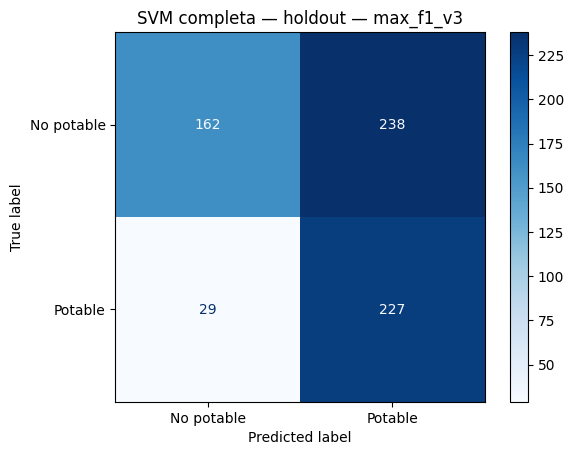

['/content/drive/MyDrive/Colab Notebooks/artifacts_v09_svm64_qsvm_ring/full_svm_pipeline.joblib']

In [7]:
# 7. Evaluación completa: OOF de entrenamiento y holdout bloqueado
full_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
training_oof_scores = cross_val_predict(
    build_full_model(random_state=SEED),
    X_train,
    y_train,
    cv=full_cv,
    method="decision_function",
    n_jobs=-1,
)

full_model = build_full_model(random_state=FINAL_MODEL_SEED)
full_model.fit(X_train, y_train)
holdout_scores = full_model.decision_function(X_test)

rows = []
for policy, threshold in FULL_THRESHOLDS.items():
    train_row = metrics_from_scores(y_train, training_oof_scores, threshold)
    train_row.update({"split": "training_oof", "policy": policy})
    rows.append(train_row)

    test_row = metrics_from_scores(y_test, holdout_scores, threshold)
    test_row.update({"split": "locked_holdout", "policy": policy})
    rows.append(test_row)

full_results = pd.DataFrame(rows)[[
    "split", "policy", "threshold", "accuracy", "precision", "recall", "f1",
    "specificity", "balanced_accuracy", "mcc", "average_precision", "roc_auc",
    "tn", "fp", "fn", "tp",
]]
display(full_results.round(4))

challenge_row = full_results.query(
    "split == 'locked_holdout' and policy == 'max_f1_v3'"
).iloc[0]
assert challenge_row["f1"] >= F1_GATE

print(f"F1 max_f1_v3 observado: {challenge_row['f1']:.4f}")
print(f"F1 de referencia:         {EXPECTED_FULL_HOLDOUT_F1:.4f}")
print(f"Diferencia absoluta:      {abs(challenge_row['f1'] - EXPECTED_FULL_HOLDOUT_F1):.6f}")

challenge_pred = (
    holdout_scores >= FULL_THRESHOLDS["max_f1_v3"]
).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    challenge_pred,
    labels=[0, 1],
    display_labels=["No potable", "Potable"],
    cmap="Blues",
)
plt.title("SVM completa — holdout — max_f1_v3")
plt.show()

full_results.to_csv(ARTIFACT_DIR / "full_svm_metrics.csv", index=False)
pd.DataFrame({
    "source_index": test_indices.astype(int),
    TARGET: y_test.to_numpy(dtype=int),
    "decision_score": holdout_scores,
    "prediction_max_f1_v3": challenge_pred,
}).to_csv(ARTIFACT_DIR / "full_svm_holdout_predictions.csv", index=False)
joblib.dump(full_model, ARTIFACT_DIR / "full_svm_pipeline.joblib")

## Parte B — Bloqueo y auditoría de las 64 muestras

Se consumen los archivos congelados de `artifacts_qsvm_input_v2`.  
No se vuelve a seleccionar ninguna observación. Los hashes garantizan que las filas y folds sean exactamente los mismos.

In [8]:
# 8. Cargar y verificar las 64 filas y sus cuatro folds
raw64_path = SOURCE_ARTIFACT_DIR / "qsvm_64_raw.csv"
folds64_path = SOURCE_ARTIFACT_DIR / "qsvm_64_folds.csv"

if not raw64_path.exists() or not folds64_path.exists():
    raise FileNotFoundError(
        "Faltan qsvm_64_raw.csv o qsvm_64_folds.csv en "
        f"{SOURCE_ARTIFACT_DIR}. Ejecute primero Gemini_TEST_Corrected_Artifacts_V2."
    )

assert sha256_file(raw64_path) == EXPECTED_RAW64_HASH
assert sha256_file(folds64_path) == EXPECTED_FOLDS64_HASH

raw64 = pd.read_csv(raw64_path)
folds64 = pd.read_csv(folds64_path).sort_values("position").reset_index(drop=True)

assert len(raw64) == len(folds64) == 64
assert raw64["source_index"].astype(int).tolist() == folds64["source_index"].astype(int).tolist()
assert raw64[TARGET].astype(int).tolist() == folds64[TARGET].astype(int).tolist()
assert Counter(raw64[TARGET].astype(int)) == Counter({0: 32, 1: 32})
assert set(raw64["source_index"].astype(int)).issubset(set(train_indices))
assert set(raw64["source_index"].astype(int)).isdisjoint(set(test_indices))
assert raw64["source_index"].nunique() == 64

fold_balance = (
    folds64.groupby(["validation_fold", TARGET])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "class_0", 1: "class_1"})
)
assert (fold_balance[["class_0", "class_1"]].to_numpy() == 8).all()

X64 = raw64[FEATURES].copy()
y64 = raw64[TARGET].astype(int).to_numpy()
fold_ids = folds64["validation_fold"].to_numpy(dtype=int)

outer_splits = []
for fold in sorted(np.unique(fold_ids)):
    validation = np.flatnonzero(fold_ids == fold)
    training = np.flatnonzero(fold_ids != fold)
    outer_splits.append((training, validation))

shutil.copy2(raw64_path, ARTIFACT_DIR / "qsvm_64_raw_LOCKED.csv")
shutil.copy2(folds64_path, ARTIFACT_DIR / "qsvm_64_folds_LOCKED.csv")

print("SHA256 raw64:", sha256_file(raw64_path))
print("SHA256 folds:", sha256_file(folds64_path))
print("Valores faltantes conservados:", int(X64.isna().sum().sum()))
display(fold_balance)
display(raw64.head())

SHA256 raw64: 18f3d62479ec83437de682b4a8b1cb0999ce2cb20f831d82564dca022a258f26
SHA256 folds: 9865e4d97868a7c93c96094062ddb3cd4fd82075a9cede748978b0455f96b98a
Valores faltantes conservados: 19


Potability,class_0,class_1
validation_fold,,
0,8,8
1,8,8
2,8,8
3,8,8


,source_index,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,127,7.371085,207.716824,24913.837166,9.616330,362.300180,363.168538,11.542662,67.720704,4.412590,0
1,41,5.331940,194.874065,16658.876503,7.993830,316.675162,335.120398,10.180514,59.572714,4.434820,0
2,3183,7.164478,213.002441,32751.928963,6.292148,NaN,490.933121,12.683767,58.252613,4.998203,1
3,1619,6.962325,205.183020,35229.077002,5.088710,254.729932,360.058960,13.617560,NaN,4.526768,1
4,549,NaN,164.378433,15908.561870,11.208688,NaN,360.814296,17.239577,60.179119,4.380978,0


## Parte C — La misma SVM sobre las 64 muestras

No se retoca `C`, `gamma`, la geometría local, Tomek Links ni el umbral.  
La única diferencia es el tamaño del conjunto: cada fold entrena con 48 filas y valida con 16.

In [9]:
# 9. SVM clásica congelada: OOF sobre las 64 filas
svm64_scores = cross_val_predict(
    build_full_model(random_state=SEED),
    X64,
    y64,
    cv=outer_splits,
    method="decision_function",
    n_jobs=-1,
)

svm64_pred_default = (svm64_scores >= 0.0).astype(int)
svm64_pred_maxf1 = (
    svm64_scores >= FULL_THRESHOLDS["max_f1_v3"]
).astype(int)

svm64_rows = []
for policy in ["default_zero", "max_f1_v3"]:
    threshold = FULL_THRESHOLDS[policy]
    row = metrics_from_scores(y64, svm64_scores, threshold)
    row.update({
        "model": "same_full_svm_pipeline_64",
        "policy": policy,
        "evaluation": "fixed_4fold_oof",
    })
    svm64_rows.append(row)

svm64_metrics = pd.DataFrame(svm64_rows)
display(svm64_metrics.round(4))

svm64_fold_rows = []
for fold, (_, validation) in enumerate(outer_splits):
    for policy in ["default_zero", "max_f1_v3"]:
        threshold = FULL_THRESHOLDS[policy]
        row = metrics_from_scores(
            y64[validation],
            svm64_scores[validation],
            threshold,
        )
        row.update({
            "fold": fold,
            "policy": policy,
            "training_rows": 48,
            "validation_rows": 16,
        })
        svm64_fold_rows.append(row)

svm64_fold_metrics = pd.DataFrame(svm64_fold_rows)
display(svm64_fold_metrics.round(4))

svm64_predictions = pd.DataFrame({
    "position": folds64["position"],
    "source_index": raw64["source_index"].astype(int),
    "validation_fold": fold_ids,
    "y_true": y64,
    "decision_score": svm64_scores,
    "prediction_default_zero": svm64_pred_default,
    "prediction_max_f1_v3": svm64_pred_maxf1,
})

svm64_metrics.to_csv(ARTIFACT_DIR / "svm64_oof_metrics.csv", index=False)
svm64_fold_metrics.to_csv(ARTIFACT_DIR / "svm64_fold_metrics.csv", index=False)
svm64_predictions.to_csv(ARTIFACT_DIR / "svm64_oof_predictions.csv", index=False)

,threshold,accuracy,precision,recall,f1,specificity,balanced_accuracy,mcc,average_precision,roc_auc,tn,fp,fn,tp,model,policy,evaluation
0,0.0000,0.6094,0.6400,0.5,0.5614,0.7188,0.6094,0.2242,0.508,0.5176,23,9,16,16,same_full_svm_pipeline_64,default_zero,fixed_4fold_oof
1,-0.9517,0.5312,0.5161,1.0,0.6809,0.0625,0.5312,0.1796,0.508,0.5176,2,30,0,32,same_full_svm_pipeline_64,max_f1_v3,fixed_4fold_oof


,threshold,accuracy,precision,recall,f1,specificity,balanced_accuracy,mcc,average_precision,roc_auc,tn,fp,fn,tp,fold,policy,training_rows,validation_rows
0,0.0000,0.6875,0.8000,0.500,0.6154,0.875,0.6875,0.4045,0.7007,0.5781,7,1,4,4,0,default_zero,48,16
1,-0.9517,0.5000,0.5000,1.000,0.6667,0.000,0.5000,0.0000,0.7007,0.5781,0,8,0,8,0,max_f1_v3,48,16
2,0.0000,0.5625,0.5714,0.500,0.5333,0.625,0.5625,0.1260,0.5011,0.4844,5,3,4,4,1,default_zero,48,16
3,-0.9517,0.5625,0.5333,1.000,0.6957,0.125,0.5625,0.2582,0.5011,0.4844,1,7,0,8,1,max_f1_v3,48,16
4,0.0000,0.4375,0.4286,0.375,0.4000,0.500,0.4375,-0.1260,0.4338,0.3594,4,4,5,3,2,default_zero,48,16
5,-0.9517,0.5625,0.5333,1.000,0.6957,0.125,0.5625,0.2582,0.4338,0.3594,1,7,0,8,2,max_f1_v3,48,16
6,0.0000,0.7500,0.8333,0.625,0.7143,0.875,0.7500,0.5164,0.7132,0.6719,7,1,3,5,3,default_zero,48,16
7,-0.9517,0.5000,0.5000,1.000,0.6667,0.000,0.5000,0.0000,0.7132,0.6719,0,8,0,8,3,max_f1_v3,48,16


## Parte D — Una sola QSVM con `pytket`

Configuración congelada:

- `pauli_Z_ZZ_ring_r1_robust`
- 9 qubits, uno por variable original
- una capa
- términos locales `Z`
- interacciones `ZZ` en anillo
- escalado `robust_atan`
- kernel de fidelidad centrado y normalizado
- `SVC(kernel="precomputed", C=10.0, class_weight="balanced")`

El preprocesamiento cuántico se ajusta exclusivamente en las 48 filas de entrenamiento de cada fold.

In [10]:
# 10. Definición de la única configuración cuántica
@dataclass(frozen=True)
class PauliMapConfig:
    name: str
    local_terms: tuple[str, ...]
    pair_terms: tuple[str, ...]
    reps: int
    topology: str
    scaling: str
    alpha: float = 1.0


PAULI_CONFIG = PauliMapConfig(
    name="pauli_Z_ZZ_ring_r1_robust",
    local_terms=("Z",),
    pair_terms=("ZZ",),
    reps=1,
    topology="ring",
    scaling="robust_atan",
    alpha=1.0,
)

assert PAULI_CONFIG.name == "pauli_Z_ZZ_ring_r1_robust"
assert PAULI_CONFIG.reps == 1
assert PAULI_CONFIG.topology == "ring"
assert N_QUBITS == 9

In [11]:
# 11. Escalado angular y circuito Pauli desde cero
class AngleScaler:
    def __init__(self, mode: str):
        if mode != "robust_atan":
            raise ValueError(f"Modo no permitido en este notebook: {mode}")
        self.mode = mode

    def fit(self, X: np.ndarray):
        X = np.asarray(X, dtype=float)
        self.center_ = np.median(X, axis=0)
        q25, q75 = np.quantile(X, [0.25, 0.75], axis=0)
        self.scale_ = np.where(q75 - q25 > 1e-12, q75 - q25, 1.0)
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        z = (X - self.center_) / self.scale_
        angles = np.pi / 2 + np.arctan(z)
        return np.clip(angles, 1e-8, np.pi - 1e-8)

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform(X)


PAULI_LOOKUP = {
    "I": Pauli.I,
    "X": Pauli.X,
    "Y": Pauli.Y,
    "Z": Pauli.Z,
}


def topology_edges(n_qubits: int, topology: str) -> list[tuple[int, int]]:
    if topology != "ring":
        raise ValueError("Este notebook permite únicamente topología ring.")
    return [(i, i + 1) for i in range(n_qubits - 1)] + [(n_qubits - 1, 0)]


def add_pauli_evolution(
    circuit: Circuit,
    word: str,
    qubits: Sequence[int],
    phi_radians: float,
) -> None:
    if len(word) != len(qubits):
        raise ValueError("La cadena de Pauli debe tener un símbolo por qubit.")

    # PauliExpBox implementa exp(-i*pi*t*P/2).
    # t = -2*phi/pi produce exp(+i*phi*P).
    t_half_turns = -2.0 * float(phi_radians) / np.pi
    box = PauliExpBox(
        [PAULI_LOOKUP[p] for p in word],
        t_half_turns,
        CXConfigType.Tree,
    )
    circuit.add_pauliexpbox(box, list(qubits))


def build_pauli_feature_map(
    angles: np.ndarray,
    config: PauliMapConfig = PAULI_CONFIG,
) -> Circuit:
    angles = np.asarray(angles, dtype=float)
    n_qubits = len(angles)
    if n_qubits != N_QUBITS:
        raise ValueError(f"Se esperaban {N_QUBITS} ángulos; se recibieron {n_qubits}.")

    circuit = Circuit(n_qubits, name=config.name)
    edges = topology_edges(n_qubits, config.topology)

    for _ in range(config.reps):
        for q in range(n_qubits):
            circuit.H(q)

        for q, theta in enumerate(angles):
            add_pauli_evolution(
                circuit,
                config.local_terms[0],
                [q],
                config.alpha * theta,
            )

        for i, j in edges:
            phi = config.alpha * (np.pi - angles[i]) * (np.pi - angles[j])
            add_pauli_evolution(
                circuit,
                config.pair_terms[0],
                [i, j],
                phi,
            )

    return circuit


def statevectors_from_angles(
    X_angles: np.ndarray,
    config: PauliMapConfig = PAULI_CONFIG,
) -> np.ndarray:
    return np.stack([
        build_pauli_feature_map(row, config).get_statevector()
        for row in np.asarray(X_angles)
    ])


def fidelity_kernel(
    states_a: np.ndarray,
    states_b: np.ndarray | None = None,
) -> np.ndarray:
    if states_b is None:
        states_b = states_a
    overlaps = np.asarray(states_a).conj() @ np.asarray(states_b).T
    kernel = np.abs(overlaps) ** 2
    return np.clip(np.real_if_close(kernel).astype(float), 0.0, 1.0)

In [12]:
# 12. Kernel centrado y normalizado sin fuga entre folds
def transform_train_cross_kernel(
    K_train: np.ndarray,
    K_cross: np.ndarray,
    eps: float = 1e-10,
) -> tuple[np.ndarray, np.ndarray]:
    K_train = np.asarray(K_train, dtype=float)
    K_cross = np.asarray(K_cross, dtype=float)

    train_col_mean = K_train.mean(axis=0)
    train_grand_mean = float(K_train.mean())

    Kt = (
        K_train
        - train_col_mean[None, :]
        - train_col_mean[:, None]
        + train_grand_mean
    )

    cross_row_mean = K_cross.mean(axis=1)
    Kx = (
        K_cross
        - cross_row_mean[:, None]
        - train_col_mean[None, :]
        + train_grand_mean
    )

    train_diag = np.sqrt(np.clip(np.diag(Kt), eps, None))
    cross_self_centered = 1.0 - 2.0 * cross_row_mean + train_grand_mean
    cross_diag = np.sqrt(np.clip(cross_self_centered, eps, None))

    Kt = Kt / np.outer(train_diag, train_diag)
    Kx = Kx / np.outer(cross_diag, train_diag)
    return (Kt + Kt.T) / 2, Kx


def fit_quantum_preprocessor(X_train: pd.DataFrame):
    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X_train)
    scaler = AngleScaler(PAULI_CONFIG.scaling)
    train_angles = scaler.fit_transform(X_imputed)
    return imputer, scaler, train_angles

In [13]:
# 13. Diagrama y recursos del único circuito
reference_angles = np.full(N_QUBITS, np.pi / 2)
reference_circuit = build_pauli_feature_map(reference_angles)

display(HTML(render_circuit_as_html(reference_circuit)))

boxed_html = render_circuit_as_html(reference_circuit)
(ARTIFACT_DIR / "pauli_Z_ZZ_ring_r1_robust_boxed.html").write_text(
    boxed_html,
    encoding="utf-8",
)

decomposed = reference_circuit.copy()
DecomposeBoxes().apply(decomposed)
(ARTIFACT_DIR / "pauli_Z_ZZ_ring_r1_robust_decomposed.qasm").write_text(
    circuit_to_qasm_str(decomposed),
    encoding="utf-8",
)

print(reference_circuit)
print("Qubits:", reference_circuit.n_qubits)
print("Compuertas antes de descomponer:", reference_circuit.n_gates)
print("Compuertas después de descomponer:", decomposed.n_gates)

<tket::Circuit, qubits=9, gates=27>
Qubits: 9
Compuertas antes de descomponer: 27
Compuertas después de descomponer: 45


In [14]:
# 14. Evaluación QSVM en los cuatro folds bloqueados
quantum_predictions = np.full(64, -1, dtype=int)
quantum_decisions = np.full(64, np.nan, dtype=float)
quantum_fold_rows = []

for fold, (training, validation) in enumerate(outer_splits):
    X_fold_train = X64.iloc[training]
    X_fold_valid = X64.iloc[validation]
    y_fold_train = y64[training]
    y_fold_valid = y64[validation]

    t0 = time.perf_counter()
    imputer, angle_scaler, train_angles = fit_quantum_preprocessor(X_fold_train)
    valid_angles = angle_scaler.transform(imputer.transform(X_fold_valid))

    train_states = statevectors_from_angles(train_angles)
    valid_states = statevectors_from_angles(valid_angles)
    statevector_seconds = time.perf_counter() - t0

    t1 = time.perf_counter()
    K_train_raw = fidelity_kernel(train_states)
    K_valid_raw = fidelity_kernel(valid_states, train_states)
    K_train, K_valid = transform_train_cross_kernel(
        K_train_raw,
        K_valid_raw,
    )
    kernel_seconds = time.perf_counter() - t1

    t2 = time.perf_counter()
    qsvc = SVC(
        kernel="precomputed",
        C=QUANTUM_C,
        class_weight="balanced",
    )
    qsvc.fit(K_train, y_fold_train)
    fold_pred = qsvc.predict(K_valid)
    fold_decision = qsvc.decision_function(K_valid)
    svc_seconds = time.perf_counter() - t2

    quantum_predictions[validation] = fold_pred
    quantum_decisions[validation] = fold_decision

    row = metrics_from_predictions(
        y_fold_valid,
        fold_pred,
        fold_decision,
    )
    row.update({
        "model": "qsvm_pytket",
        "map": PAULI_CONFIG.name,
        "kernel_mode": QUANTUM_KERNEL_MODE,
        "C": QUANTUM_C,
        "fold": fold,
        "training_rows": len(training),
        "validation_rows": len(validation),
        "statevector_seconds": statevector_seconds,
        "kernel_seconds": kernel_seconds,
        "svc_seconds": svc_seconds,
    })
    quantum_fold_rows.append(row)

    np.savez_compressed(
        ARTIFACT_DIR / f"qsvm_ring_fold_{fold}.npz",
        train_positions=training,
        validation_positions=validation,
        y_train=y_fold_train,
        y_validation=y_fold_valid,
        K_train_raw=K_train_raw,
        K_validation_raw=K_valid_raw,
        K_train_centered_normalized=K_train,
        K_validation_centered_normalized=K_valid,
    )

assert (quantum_predictions >= 0).all()
assert np.isfinite(quantum_decisions).all()

quantum_fold_metrics = pd.DataFrame(quantum_fold_rows)
quantum_oof_metrics = pd.DataFrame([{
    "model": "qsvm_pytket",
    "map": PAULI_CONFIG.name,
    "kernel_mode": QUANTUM_KERNEL_MODE,
    "C": QUANTUM_C,
    "evaluation": "fixed_4fold_oof",
    **metrics_from_predictions(y64, quantum_predictions, quantum_decisions),
}])

quantum_oof_predictions = pd.DataFrame({
    "position": folds64["position"],
    "source_index": raw64["source_index"].astype(int),
    "validation_fold": fold_ids,
    "y_true": y64,
    "y_pred": quantum_predictions,
    "decision_score": quantum_decisions,
})

display(quantum_fold_metrics.round(4))
display(quantum_oof_metrics.round(4))

quantum_fold_metrics.to_csv(
    ARTIFACT_DIR / "qsvm_ring_fold_metrics.csv",
    index=False,
)
quantum_oof_metrics.to_csv(
    ARTIFACT_DIR / "qsvm_ring_oof_metrics.csv",
    index=False,
)
quantum_oof_predictions.to_csv(
    ARTIFACT_DIR / "qsvm_ring_oof_predictions.csv",
    index=False,
)

,accuracy,precision,recall,f1,specificity,balanced_accuracy,mcc,tn,fp,fn,tp,average_precision,roc_auc,model,map,kernel_mode,C,fold,training_rows,validation_rows,statevector_seconds,kernel_seconds,svc_seconds
0,0.5625,0.5714,0.500,0.5333,0.625,0.5625,0.1260,5,3,4,4,0.6168,0.5938,qsvm_pytket,pauli_Z_ZZ_ring_r1_robust,centered_normalized,10.0,0,48,16,0.4136,0.0149,0.0092
1,0.6875,0.6667,0.750,0.7059,0.625,0.6875,0.3780,5,3,2,6,0.6830,0.6875,qsvm_pytket,pauli_Z_ZZ_ring_r1_robust,centered_normalized,10.0,1,48,16,0.4476,0.0013,0.0028
2,0.5000,0.5000,0.375,0.4286,0.625,0.5000,0.0000,5,3,5,3,0.6751,0.6719,qsvm_pytket,pauli_Z_ZZ_ring_r1_robust,centered_normalized,10.0,2,48,16,0.2522,0.0012,0.0028
3,0.5625,0.5455,0.750,0.6316,0.375,0.5625,0.1348,3,5,2,6,0.5945,0.5469,qsvm_pytket,pauli_Z_ZZ_ring_r1_robust,centered_normalized,10.0,3,48,16,0.4484,0.0316,0.0050


,model,map,kernel_mode,C,evaluation,accuracy,precision,recall,f1,specificity,balanced_accuracy,mcc,tn,fp,fn,tp,average_precision,roc_auc
0,qsvm_pytket,pauli_Z_ZZ_ring_r1_robust,centered_normalized,10.0,fixed_4fold_oof,0.5781,0.5758,0.5938,0.5846,0.5625,0.5781,0.1563,18,14,13,19,0.5938,0.6074


## Parte E — Resumen y trazabilidad

La tabla siguiente junta resultados con distinto alcance:

- `full_svm_locked_holdout`: rendimiento principal del modelo clásico en 656 filas bloqueadas;
- `same_svm_64_oof`: base clásica en las 64 filas;
- `qsvm_ring_64_oof`: única versión cuántica en exactamente las mismas 64 filas y folds.

Por ello, la comparación directa SVM–QSVM debe hacerse entre las dos filas de 64 muestras, no contra el holdout completo.

In [15]:
# 15. Resumen comparable
summary_rows = [
    {
        "experiment": "full_svm_locked_holdout",
        "samples": len(y_test),
        "policy_or_kernel": "max_f1_v3",
        **challenge_row[[
            "accuracy", "precision", "recall", "f1",
            "specificity", "balanced_accuracy", "mcc",
        ]].to_dict(),
    },
    {
        "experiment": "same_svm_64_oof",
        "samples": 64,
        "policy_or_kernel": "max_f1_v3",
        **svm64_metrics.query("policy == 'max_f1_v3'").iloc[0][[
            "accuracy", "precision", "recall", "f1",
            "specificity", "balanced_accuracy", "mcc",
        ]].to_dict(),
    },
    {
        "experiment": "qsvm_ring_64_oof",
        "samples": 64,
        "policy_or_kernel": "centered_normalized",
        **quantum_oof_metrics.iloc[0][[
            "accuracy", "precision", "recall", "f1",
            "specificity", "balanced_accuracy", "mcc",
        ]].to_dict(),
    },
]

comparison_summary = pd.DataFrame(summary_rows)
display(comparison_summary.round(4))
comparison_summary.to_csv(
    ARTIFACT_DIR / "FINAL_COMPARISON_SUMMARY.csv",
    index=False,
)

,experiment,samples,policy_or_kernel,accuracy,precision,recall,f1,specificity,balanced_accuracy,mcc
0,full_svm_locked_holdout,656,max_f1_v3,0.5930,0.4882,0.8867,0.6297,0.4050,0.6459,0.3132
1,same_svm_64_oof,64,max_f1_v3,0.5312,0.5161,1.0000,0.6809,0.0625,0.5312,0.1796
2,qsvm_ring_64_oof,64,centered_normalized,0.5781,0.5758,0.5938,0.5846,0.5625,0.5781,0.1563


In [16]:
# 16. Comprobaciones y manifiesto final
checks = {
    "dataset_has_3276_rows": len(df) == 3276,
    "split_before_preprocessing": True,
    "holdout_not_used_for_selection": True,
    "full_model_uses_frozen_params": True,
    "full_holdout_f1_gate_passed": bool(challenge_row["f1"] >= F1_GATE),
    "raw64_hash_matches": sha256_file(raw64_path) == EXPECTED_RAW64_HASH,
    "folds64_hash_matches": sha256_file(folds64_path) == EXPECTED_FOLDS64_HASH,
    "subset64_balanced_32_32": Counter(y64) == Counter({0: 32, 1: 32}),
    "subset64_training_pool_only": set(raw64["source_index"]).issubset(set(train_indices)),
    "subset64_no_holdout_overlap": set(raw64["source_index"]).isdisjoint(set(test_indices)),
    "four_folds_are_8_8": bool((fold_balance.to_numpy() == 8).all()),
    "classical64_is_exact_same_pipeline": True,
    "one_quantum_map_only": PAULI_CONFIG.name == "pauli_Z_ZZ_ring_r1_robust",
    "quantum_uses_all_9_original_features": N_QUBITS == len(FEATURES) == 9,
    "quantum_preprocessing_is_fold_local": True,
    "quantum_C_is_frozen": QUANTUM_C == 10.0,
    "quantum_kernel_mode_is_frozen": QUANTUM_KERNEL_MODE == "centered_normalized",
    "no_qiskit_imported": not any(name.startswith("qiskit") for name in sys.modules),
}
assert all(checks.values())

manifest = {
    "project": "Challenge 2 — full SVM + same SVM/QSVM on locked 64",
    "source_notebooks": {
        "classical": "Gemini_TEST_Corrected_Artifacts_V2.ipynb",
        "pytket": "V08_Challenge2_pytket_PauliFeatureMap_From_Scratch.ipynb",
    },
    "dataset": {
        "path_at_execution": str(DATA_PATH),
        "sha256": dataset_sha256,
        "rows": len(df),
        "features": FEATURES,
        "target": TARGET,
    },
    "full_svm": {
        "params": FULL_PARAMS,
        "thresholds": FULL_THRESHOLDS,
        "final_model_seed": FINAL_MODEL_SEED,
        "observed_holdout_f1_max_f1_v3": float(challenge_row["f1"]),
    },
    "subset64": {
        "raw_sha256": sha256_file(raw64_path),
        "folds_sha256": sha256_file(folds64_path),
        "rows": 64,
        "class_counts": {"0": 32, "1": 32},
        "folds": 4,
    },
    "quantum": {
        "config": asdict(PAULI_CONFIG),
        "n_qubits": N_QUBITS,
        "features": FEATURES,
        "kernel_mode": QUANTUM_KERNEL_MODE,
        "C": QUANTUM_C,
    },
    "checks": checks,
    "environment": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "imbalanced_learn": imblearn.__version__,
        "pytket": pytket.__version__,
    },
}

write_json(ARTIFACT_DIR / "FINAL_MANIFEST.json", manifest)
pd.DataFrame(
    [{"check": key, "passed": value} for key, value in checks.items()]
).to_csv(ARTIFACT_DIR / "REPRODUCIBILITY_CHECKS.csv", index=False)

print("✅ Notebook completado.")
print("Artefactos:", ARTIFACT_DIR)
for path in sorted(ARTIFACT_DIR.iterdir()):
    if path.is_file():
        print("-", path.name)

✅ Notebook completado.
Artefactos: /content/drive/MyDrive/Colab Notebooks/artifacts_v09_svm64_qsvm_ring
- FINAL_COMPARISON_SUMMARY.csv
- FINAL_MANIFEST.json
- REPRODUCIBILITY_CHECKS.csv
- full_svm_holdout_predictions.csv
- full_svm_metrics.csv
- full_svm_pipeline.joblib
- pauli_Z_ZZ_ring_r1_robust_boxed.html
- pauli_Z_ZZ_ring_r1_robust_decomposed.qasm
- qsvm_64_folds_LOCKED.csv
- qsvm_64_raw_LOCKED.csv
- qsvm_ring_fold_0.npz
- qsvm_ring_fold_1.npz
- qsvm_ring_fold_2.npz
- qsvm_ring_fold_3.npz
- qsvm_ring_fold_metrics.csv
- qsvm_ring_oof_metrics.csv
- qsvm_ring_oof_predictions.csv
- svm64_fold_metrics.csv
- svm64_oof_metrics.csv
- svm64_oof_predictions.csv


## Interpretación final

- El resultado principal clásico sigue siendo el de `max_f1_v3` en el holdout bloqueado completo.
- La SVM de 64 filas usa el mismo pipeline y el mismo umbral; no se ha optimizado para ese subconjunto.
- La QSVM usa una sola configuración Pauli, elegida antes de este experimento.
- Diferencias pequeñas en las métricas pueden aparecer si se cambian las versiones fijadas de `scikit-learn`, `imbalanced-learn` o `pytket`.
- Para ejecutar en hardware real de Quantinuum habría que añadir backend, compilación dirigida, shots y mitigación; este notebook calcula el kernel exacto mediante statevectors de `pytket`.